In [6]:
import pandas as pd
import matplotlib.pyplot as plt 

In [7]:
#pendiente: ver aproximadamente cual es el despacho de las termicas, cotejar si coincide con real data, revisar costos de banrep estiamdos con arrnque y parada
#medida es megavatios hora, costo es pesos por megavatio hora, valor total es pesos por dia (porque estoy sumando el costo de cada hora del dia)

In [ ]:
import pandas as pd
import numpy as np
import ast

def construir_df_planta(df):
    def metrics_fila(row):
        q = np.array(ast.literal_eval(row["cantidades_despachadas"]), dtype=float)
        p = np.array(ast.literal_eval(row["precio24"]), dtype=float)
        phi = np.array(ast.literal_eval(row["phi"]), dtype=float)

        payment = q * p
        markup = payment - phi * q
        markup = np.maximum(markup, 0)  # truncar negativos

        return pd.Series({
            "mean_payment": np.mean(payment),
            "mean_markup": np.mean(markup)
        })

    df_metrics = df.apply(metrics_fila, axis=1)

    df_out = (
        pd.concat([df[["id_planta"]], df_metrics], axis=1)
          .groupby("id_planta", as_index=False)
          .mean()
    )

    return df_out





In [9]:
import pandas as pd
import numpy as np
import ast

def construir_df_planta_asymetric(df):
    df= df[df['t']==49]
    def metrics_fila(row):
        q = np.array(ast.literal_eval(row["q_dispatch24"]), dtype=float)
        p = np.array(ast.literal_eval(row["price_paid24"]), dtype=float)
        phi = np.array(ast.literal_eval(row["phi24"]), dtype=float)

        payment = q * p
        markup = payment - phi * q
        markup = np.maximum(markup, 0)  # truncar negativos

        return pd.Series({
            "mean_payment": np.mean(payment),
            "mean_markup": np.mean(markup)
        })

    df_metrics = df.apply(metrics_fila, axis=1)

    df_out = (
        pd.concat([df[["id_planta"]], df_metrics], axis=1)
          .groupby("id_planta", as_index=False)
          .mean()
    )

    return df_out


In [10]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def dumbbell_mean_metrics_by_planta(
    df_uniform,
    df_discriminatory,
    *,
    plot_metric="mean_markup",          # "mean_markup" o "mean_payment"
    top_n=40,
    truncate_negative_markup=True,      # replica np.maximum(markup,0)
    vec_len=24,
    q_col="cantidades_despachadas",
    p_col="precio24",
    phi_col="phi",
    id_col="id_planta",
    h_col="h",                          # bootstrap/sim index; se promedia sobre h
    t_col="t",                          # si existe, toma último t por (id,h)
    orientation="vertical",             # "vertical" (plantas en x) o "horizontal"
    rotate_xticks=60,
    paper_style=True,
    save_prefix="dumbbell_mean",
):
    """
    Define por FILA (una simulación/boot):
      payment_vec = q*p
      markup_vec  = payment_vec - phi*q = (p-phi)*q
      mean_payment_row = mean(payment_vec)  (promedio sobre 24 horas)
      mean_markup_row  = mean(max(markup_vec,0)) si truncate_negative_markup=True

    Define por PLANTA:
      mean_metric_planta = mean_h(mean_metric_row)  (promedio sobre bootstraps h)

    Produce dumbbell publicable (PDF vector) comparando Uniforme vs Discriminatorio.
    Retorna: (cmp_plot, fig, cmp_all, uni_i, disc_i)
    """

    # -------------------------
    # parsing robusto
    # -------------------------
    def _parse_any(x):
        if isinstance(x, list):
            return x
        if isinstance(x, (tuple, np.ndarray)):
            return list(x)
        if pd.isna(x):
            return None
        if isinstance(x, str):
            s = x.strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    v = ast.literal_eval(s)
                    return v if isinstance(v, list) else None
                except Exception:
                    return None
        if isinstance(x, (int, float, np.integer, np.floating)):
            return float(x)
        return None

    def _to_vec(x, *, allow_scalar=False):
        v = _parse_any(x)
        if isinstance(v, (float, int, np.integer, np.floating)):
            if not allow_scalar:
                return np.full(vec_len, np.nan, dtype=float)
            return np.full(vec_len, float(v), dtype=float)
        if isinstance(v, list):
            arr = np.array(v, dtype=float)
            if arr.size < vec_len:
                arr = np.concatenate([arr, np.full(vec_len - arr.size, np.nan)])
            elif arr.size > vec_len:
                arr = arr[:vec_len]
            return arr
        return np.full(vec_len, np.nan, dtype=float)

    def _ensure_cols(df, name):
        for c in [id_col, q_col, p_col, phi_col]:
            if c not in df.columns:
                raise KeyError(f"{name} missing column: {c}")

    def _keep_last_t_if_needed(df):
        out = df.copy()
        if t_col in out.columns:
            out[t_col] = pd.to_numeric(out[t_col], errors="coerce")
            if h_col in out.columns:
                out[h_col] = pd.to_numeric(out[h_col], errors="coerce")
                out = out.sort_values([id_col, h_col, t_col]).groupby([id_col, h_col], as_index=False).tail(1)
            else:
                out = out.sort_values([id_col, t_col]).groupby([id_col], as_index=False).tail(1)
        return out

    def _metrics_by_planta(df):
        df = _keep_last_t_if_needed(df)

        def _row_metrics(row):
            q = _to_vec(row[q_col], allow_scalar=False)
            p = _to_vec(row[p_col], allow_scalar=False)
            phi = _to_vec(row[phi_col], allow_scalar=True)

            payment_vec = q * p
            markup_vec = payment_vec - phi * q

            if truncate_negative_markup:
                markup_vec = np.maximum(markup_vec, 0.0)

            return pd.Series({
                "mean_payment": float(np.nanmean(payment_vec)),
                "mean_markup":  float(np.nanmean(markup_vec)),
            })

        m = df.apply(_row_metrics, axis=1)
        tmp_cols = [id_col] + ([h_col] if h_col in df.columns else [])
        tmp = pd.concat([df[tmp_cols], m], axis=1)

        if h_col in tmp.columns:
            tmp[h_col] = pd.to_numeric(tmp[h_col], errors="coerce")

            # si hay duplicados por (id,h), promediar dentro de h primero
            by_ih = (tmp.groupby([id_col, h_col], as_index=False)
                        .agg(mean_payment=("mean_payment", "mean"),
                             mean_markup=("mean_markup", "mean")))

            by_i = (by_ih.groupby(id_col, as_index=False)
                        .agg(mean_payment=("mean_payment", "mean"),
                             mean_markup=("mean_markup", "mean"),
                             n_boot=(h_col, "nunique")))
        else:
            by_i = (tmp.groupby(id_col, as_index=False)
                        .agg(mean_payment=("mean_payment", "mean"),
                             mean_markup=("mean_markup", "mean"),
                             n_boot=("mean_payment", "count")))

        return by_i

    # -------------------------
    # compute
    # -------------------------
    _ensure_cols(df_uniform, "df_uniform")
    _ensure_cols(df_discriminatory, "df_discriminatory")

    uni_i  = _metrics_by_planta(df_uniform).rename(columns={
        "mean_payment": "mean_payment_uni",
        "mean_markup":  "mean_markup_uni",
        "n_boot":       "n_boot_uni"
    })
    disc_i = _metrics_by_planta(df_discriminatory).rename(columns={
        "mean_payment": "mean_payment_disc",
        "mean_markup":  "mean_markup_disc",
        "n_boot":       "n_boot_disc"
    })

    cmp_all = uni_i.merge(disc_i, on=id_col, how="outer")
    cmp_all["d_mean_payment"] = cmp_all["mean_payment_uni"] - cmp_all["mean_payment_disc"]
    cmp_all["d_mean_markup"]  = cmp_all["mean_markup_uni"]  - cmp_all["mean_markup_disc"]

    if plot_metric not in ["mean_payment", "mean_markup"]:
        raise ValueError("plot_metric must be 'mean_payment' or 'mean_markup'")

    L = f"{plot_metric}_disc"
    R = f"{plot_metric}_uni"
    D = f"d_{plot_metric}"

    cmp_plot = (cmp_all.dropna(subset=[L, R])
                      .assign(abs_d=lambda d: d[D].abs())
                      .sort_values("abs_d", ascending=False)
                      .head(top_n)
                      .sort_values(D, ascending=True)
                      .reset_index(drop=True))

    # -------------------------
    # paper style + colores (Okabe–Ito)
    # -------------------------
    if paper_style:
        plt.rcParams.update({
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "legend.fontsize": 9,
            "axes.linewidth": 0.8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
        })

    c_disc = "#0072B2"   # azul
    c_uni  = "#D55E00"   # rojo-naranja
    c_line = "#6E6E6E"   # gris

    # -------------------------
    # plot
    # -------------------------
    if orientation not in ["vertical", "horizontal"]:
        raise ValueError("orientation must be 'vertical' or 'horizontal'")

    if orientation == "vertical":
        x = np.arange(len(cmp_plot))
        y_disc = cmp_plot[L].to_numpy(dtype=float)
        y_uni  = cmp_plot[R].to_numpy(dtype=float)

        fig = plt.figure(figsize=(max(8, 0.35 * len(cmp_plot)), 4.2))
        plt.vlines(x, y_disc, y_uni, linewidth=1.6, color=c_line, alpha=0.9, zorder=1)
        plt.scatter(x, y_disc, s=36, color=c_disc, edgecolor="white", linewidth=0.6,
                    label="Discriminatorio", zorder=3)
        plt.scatter(x, y_uni,  s=36, color=c_uni,  edgecolor="white", linewidth=0.6,
                    label="Uniforme", zorder=3)

        plt.xticks(x, cmp_plot[id_col].astype(str), rotation=rotate_xticks, ha="right")
        if plot_metric == "mean_payment":
            plt.ylabel("Mean payment (millon COP/day)")
            plt.title(f"Mean payment by plant")
        else:  
            plt.ylabel("Mean markup (millon COP/day)")
            plt.title(f"Mean markup by plant")
        plt.grid(axis="y", linewidth=0.5, alpha=0.25)
        plt.legend(frameon=False, ncol=2, loc="upper right")
        plt.tight_layout()

       
        plt.savefig(f"{save_prefix}_{plot_metric}_vertical.png", dpi=300, bbox_inches="tight")
        plt.show()

    else:
        y = np.arange(len(cmp_plot))
        xL = cmp_plot[L].to_numpy(dtype=float)
        xR = cmp_plot[R].to_numpy(dtype=float)

        fig = plt.figure(figsize=(10, max(4, 0.35 * len(cmp_plot))))
        plt.hlines(y, xL, xR, linewidth=1.6, color=c_line, alpha=0.9, zorder=1)
        plt.scatter(xL, y, s=36, color=c_disc, edgecolor="white", linewidth=0.6,
                    label="Discriminatorio", zorder=3)
        plt.scatter(xR, y, s=36, color=c_uni,  edgecolor="white", linewidth=0.6,
                    label="Uniforme", zorder=3)

        plt.yticks(y, cmp_plot[id_col].astype(str))
        plt.xlabel(plot_metric)
        plt.title(f"{plot_metric} por planta: Uniforme vs Discriminatorio")
        plt.grid(axis="x", linewidth=0.5, alpha=0.25)
        plt.legend(frameon=False, ncol=2, loc="lower right")
        plt.tight_layout()

        plt.savefig(f"{save_prefix}_{plot_metric}_horizontal.pdf", bbox_inches="tight")
        plt.savefig(f"{save_prefix}_{plot_metric}_horizontal.png", dpi=300, bbox_inches="tight")
        plt.show()

    return cmp_plot, fig, cmp_all, uni_i, disc_i


In [11]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_system_mean_payment_over_h_paper(
    df_uniform,
    df_discriminatory,
    *,
    vec_len=24,
    q_col="cantidades_despachadas",
    p_col="precio24",
    id_col="id_planta",
    h_col="h",
    t_col="t",
    agg_across_plants="sum",      # "sum" recomendado para gasto del sistema
    show_quantile_band=True,
    band_q=(10, 90),
    show_points=True,
    smooth_window=0,             # 0: sin smoothing; >1: rolling mean (solo estética)
    save_prefix="fig_system_mean_payment_over_h",
):
    def _parse_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, (tuple, np.ndarray)):
            return list(x)
        if pd.isna(x):
            return None
        if isinstance(x, str):
            s = x.strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    v = ast.literal_eval(s)
                    return v if isinstance(v, list) else None
                except Exception:
                    return None
        return None

    def _to_vec24(x):
        v = _parse_list(x)
        if v is None:
            return np.full(vec_len, np.nan, dtype=float)
        arr = np.array(v, dtype=float)
        if arr.size < vec_len:
            arr = np.concatenate([arr, np.full(vec_len - arr.size, np.nan)])
        elif arr.size > vec_len:
            arr = arr[:vec_len]
        return arr

    def _keep_last_t(df):
        out = df.copy()
        if t_col in out.columns:
            out[t_col] = pd.to_numeric(out[t_col], errors="coerce")
            out[h_col] = pd.to_numeric(out[h_col], errors="coerce")
            out = out.sort_values([id_col, h_col, t_col]).groupby([id_col, h_col], as_index=False).tail(1)
        return out

    def _system_series(df):
        for c in [id_col, h_col, q_col, p_col]:
            if c not in df.columns:
                raise KeyError(f"missing column: {c}")

        df = _keep_last_t(df).copy()
        df[h_col] = pd.to_numeric(df[h_col], errors="coerce")

        def _row_mean_payment(row):
            q = _to_vec24(row[q_col])
            p = _to_vec24(row[p_col])
            return float(np.nanmean(q * p))

        tmp = df[[id_col, h_col]].copy()
        tmp["mean_payment_row"] = df.apply(_row_mean_payment, axis=1)

        by_ih = (tmp.groupby([id_col, h_col], as_index=False)
                   .agg(mean_payment_row=("mean_payment_row", "mean")))

        if agg_across_plants == "sum":
            by_h = (by_ih.groupby(h_col, as_index=False)
                      .agg(system_mean_payment=("mean_payment_row", "sum")))
        elif agg_across_plants == "mean":
            by_h = (by_ih.groupby(h_col, as_index=False)
                      .agg(system_mean_payment=("mean_payment_row", "mean")))
        else:
            raise ValueError("agg_across_plants must be 'sum' or 'mean'")

        by_h = by_h.sort_values(h_col).reset_index(drop=True)

        if smooth_window and smooth_window > 1:
            by_h["system_smooth"] = by_h["system_mean_payment"].rolling(smooth_window, min_periods=1).mean()
        else:
            by_h["system_smooth"] = by_h["system_mean_payment"]

        return by_h

    uni_h  = _system_series(df_uniform)
    disc_h = _system_series(df_discriminatory)

    merged = (uni_h[[h_col, "system_mean_payment", "system_smooth"]]
                .rename(columns={"system_mean_payment":"uni", "system_smooth":"uni_smooth"})
              .merge(disc_h[[h_col, "system_mean_payment", "system_smooth"]]
                .rename(columns={"system_mean_payment":"disc", "system_smooth":"disc_smooth"}),
                on=h_col, how="outer")
              .sort_values(h_col)
              .reset_index(drop=True))

    # colores Okabe–Ito
    c_uni  = "#D55E00"
    c_disc = "#0072B2"
    c_grid = "#B0B0B0"

    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    fig = plt.figure(figsize=(8.6, 4.2))

    # banda p10–p90 SOBRE h (sistema)
    if show_quantile_band:
        qlo, qhi = band_q
        disc_lo = np.nanpercentile(merged["disc"], qlo)
        disc_hi = np.nanpercentile(merged["disc"], qhi)
        uni_lo  = np.nanpercentile(merged["uni"],  qlo)
        uni_hi  = np.nanpercentile(merged["uni"],  qhi)

        x = merged[h_col].to_numpy()
        plt.fill_between(x, disc_lo, disc_hi, color=c_disc, alpha=0.10, linewidth=0)
        plt.fill_between(x, uni_lo,  uni_hi,  color=c_uni,  alpha=0.10, linewidth=0)

    # puntos (cada h)
    if show_points:
        plt.scatter(merged[h_col], merged["disc"], s=14, color=c_disc, alpha=0.25, edgecolor="none")
        plt.scatter(merged[h_col], merged["uni"],  s=14, color=c_uni,  alpha=0.25, edgecolor="none")

    # líneas (suave si pides smoothing)
    plt.plot(merged[h_col], merged["disc_smooth"], color=c_disc, linewidth=2.2, label="Discriminatorio")
    plt.plot(merged[h_col], merged["uni_smooth"],  color=c_uni,  linewidth=2.2, label="Uniforme")

    plt.grid(axis="y", color=c_grid, linewidth=0.5, alpha=0.35)
    plt.xlabel("Bootstrap h")
    ylabel = "System mean payment (sum over plants)" if agg_across_plants == "sum" else "Mean payment (avg over plants)"
    plt.ylabel(ylabel)

    title = "Gasto del comprador por bootstrap h"
    if smooth_window and smooth_window > 1:
        title += f" (rolling mean {smooth_window})"
    if show_quantile_band:
        title += f" + banda p{band_q[0]}–p{band_q[1]} (sobre h)"
    plt.title(title)

    plt.legend(frameon=False, ncol=2, loc="upper left")
    plt.tight_layout()

    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_prefix}.png", bbox_inches="tight")
    plt.show()

    return merged


## 1 red

In [12]:
panel_uniforme1 = pd.read_csv('1red/panel_uniform1R.csv')
panel_uniforme1.head()

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,2.676840,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.564928,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.467680,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,2.041678,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,2.037606,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ...","[2.073489846421242, 2.037606479359627, 0.0, 0....","[0.18770034673480002, 0.18770034673480002, 0.1..."


In [13]:
panel_pay_as_bid1 = pd.read_csv('1red/panel_pay_as_bid1R.csv')
panel_pay_as_bid1.head()

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,3.127851,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.904173,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.820375,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,2.595516,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,2.591969,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ...","[2.591969134045601, 2.591969134045601, 0.0, 0....","[0.18770034673480002, 0.18770034673480002, 0.1..."


In [14]:

construir_df_planta(panel_pay_as_bid1)


,id_planta,mean_payment,mean_markup
0,1,22.489643,17.826940
1,2,1.783263,1.693507
2,3,1.062478,0.914006
3,4,0.002946,0.002742
4,5,356.396371,339.748340
5,6,4.982130,4.472109
6,7,0.004499,0.004054
7,8,1.093395,1.011818
8,9,101.451529,94.157855
9,10,341.289956,327.822920


In [15]:
construir_df_planta(panel_uniforme1).sum()

id_planta        666.000000
mean_payment    2670.603550
mean_markup     2429.663122
dtype: float64

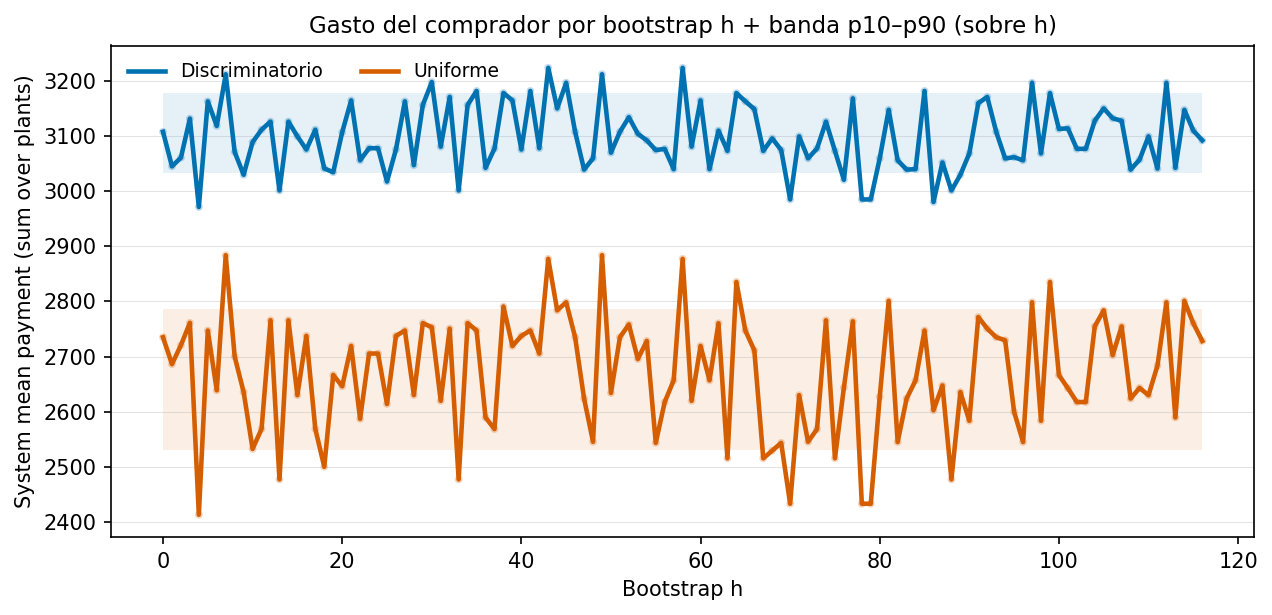

In [16]:
merged = plot_system_mean_payment_over_h_paper(
    panel_uniforme1,
    panel_pay_as_bid1,
    agg_across_plants="sum",   # gasto sistema
    smooth_window=0,           # o 5 para suavizar
    save_prefix="system_mean_payment_over_h"
)


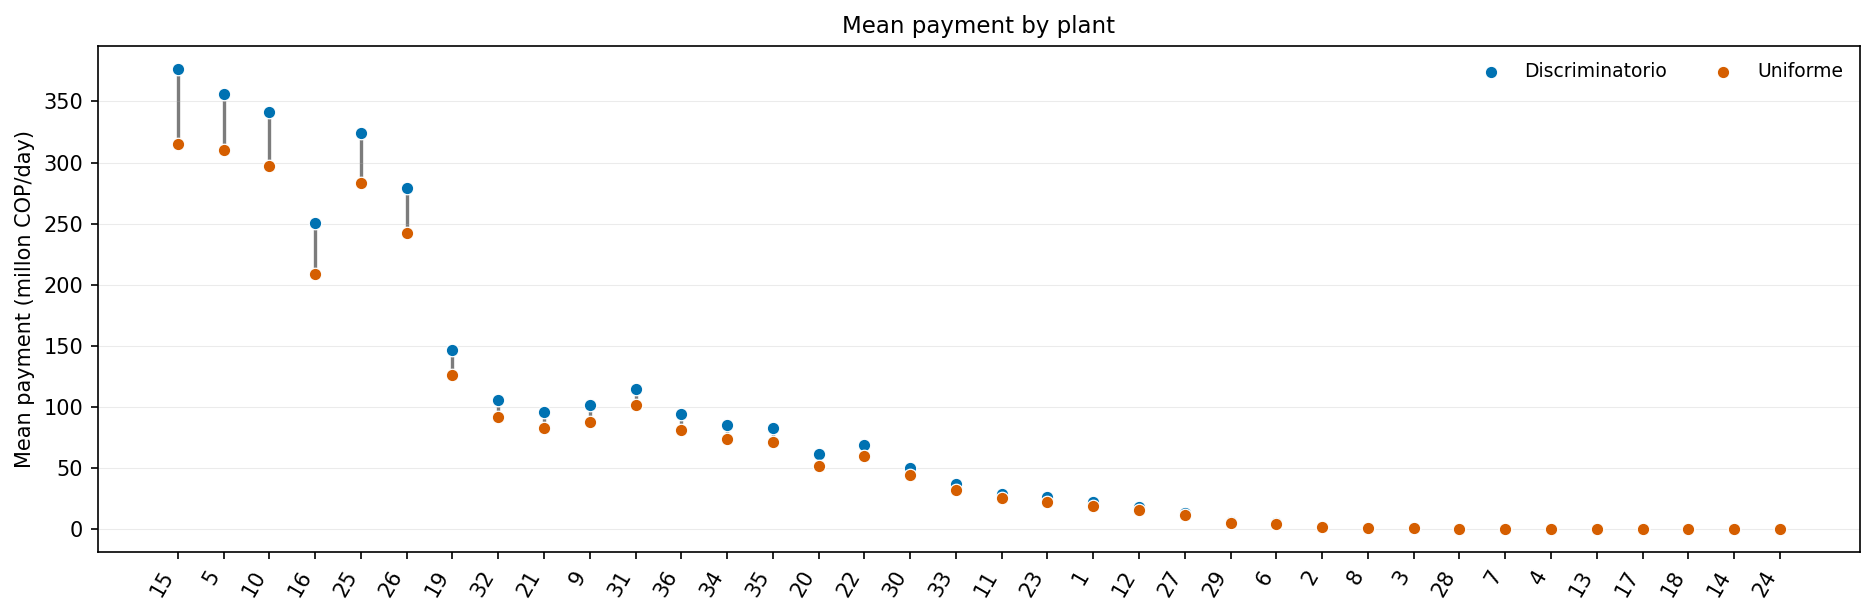

(    id_planta  mean_payment_uni  mean_markup_uni  n_boot_uni  \
 0          15        314.845386       268.458013         117   
 1           5        310.215242       293.567211         117   
 2          10        297.454297       283.987261         117   
 3          16        208.870743       170.889329         117   
 4          25        283.071907       267.294255         117   
 5          26        242.625125       227.379905         117   
 6          19        125.881414       116.836202         117   
 7          32         91.801629        87.158285         117   
 8          21         82.591632        68.864084         117   
 9           9         88.130049        80.836374         117   
 10         31        101.789135        99.836652         117   
 11         36         81.482934        71.984612         117   
 12         34         73.993478        66.810991         117   
 13         35         71.806260        62.820621         117   
 14         20         51

In [17]:
dumbbell_mean_metrics_by_planta(panel_uniforme1, panel_pay_as_bid1, plot_metric="mean_payment")

## 3 redes

In [18]:
panel_uniforme3 = pd.read_csv('3redes/panel_uniform3R.csv')
construir_df_planta(panel_uniforme3).sum()


id_planta        666.000000
mean_payment    1379.860047
mean_markup      994.492556
dtype: float64

In [19]:
panel_pay_as_bid3 = pd.read_csv('3redes/panel_pay_as_bid3R.csv')
construir_df_planta(panel_pay_as_bid3).sum()

id_planta       666.000000
mean_payment    930.948591
mean_markup     418.104692
dtype: float64

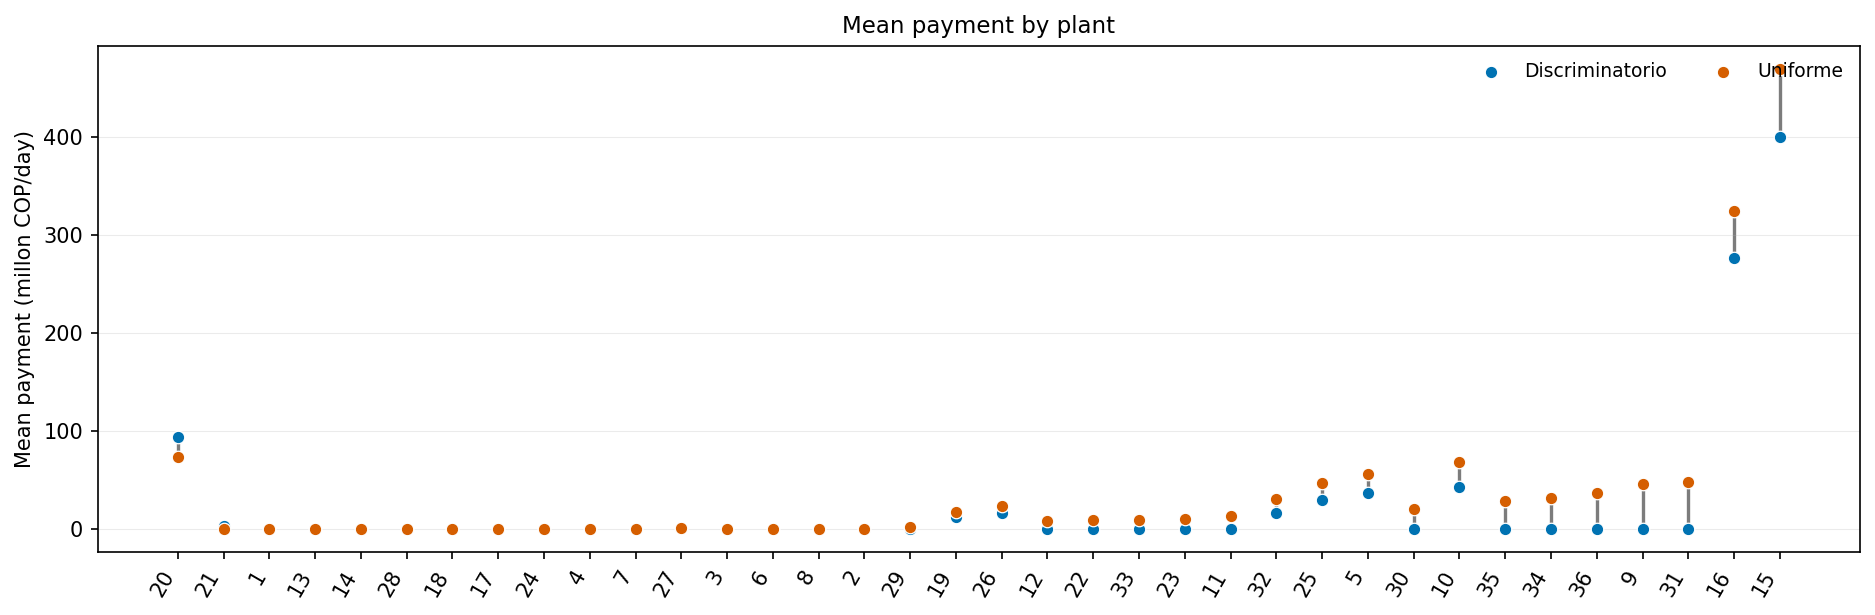

(    id_planta  mean_payment_uni  mean_markup_uni  n_boot_uni  \
 0          20         73.477047        45.296358         117   
 1          21          0.327028         0.232981         117   
 2           1          0.000000         0.000000         117   
 3          13          0.000000         0.000000         117   
 4          14          0.000000         0.000000         117   
 5          28          0.000000         0.000000         117   
 6          18          0.000000         0.000000         117   
 7          17          0.000000         0.000000         117   
 8          24          0.000000         0.000000         117   
 9           4          0.001150         0.001025         117   
 10          7          0.001817         0.001434         117   
 11         27          0.879189         0.851753         117   
 12          3          0.103498         0.075016         117   
 13          6          0.529090         0.487581         117   
 14          8          0

In [20]:
dumbbell_mean_metrics_by_planta(panel_uniforme3, panel_pay_as_bid3, plot_metric="mean_payment" )

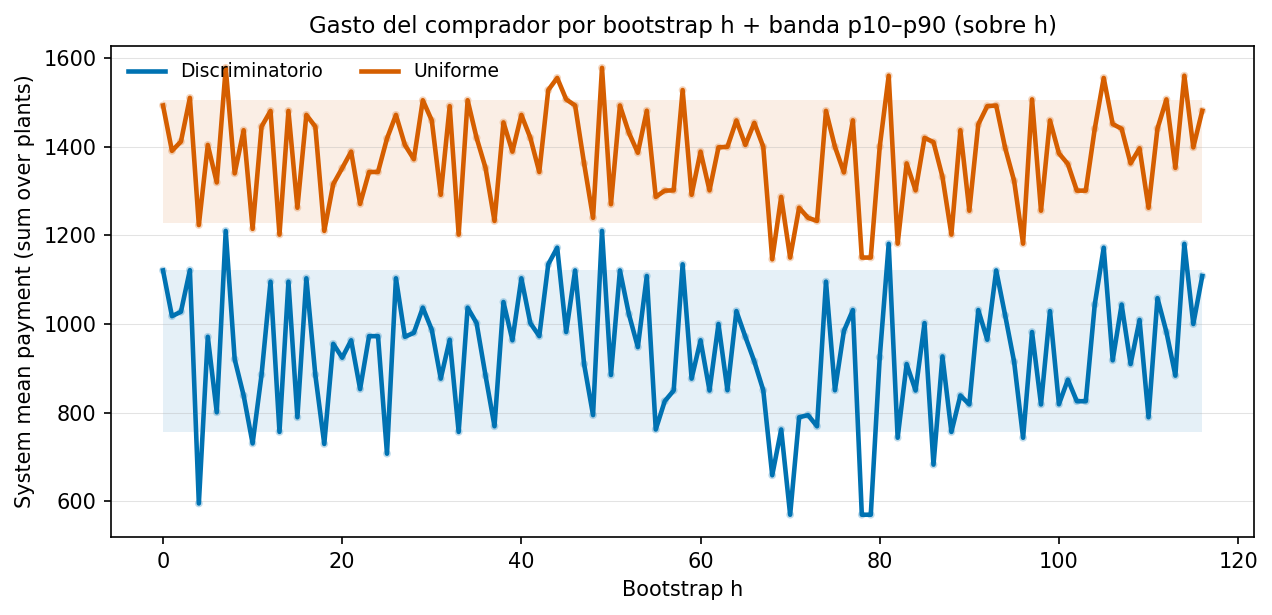

,h,uni,uni_smooth,disc,disc_smooth
0,0,1492.536263,1492.536263,1120.612802,1120.612802
1,1,1390.204743,1390.204743,1017.487664,1017.487664
2,2,1411.179819,1411.179819,1027.438574,1027.438574
3,3,1509.733218,1509.733218,1121.205756,1121.205756
4,4,1222.941191,1222.941191,595.209938,595.209938
...,...,...,...,...,...
112,112,1506.297023,1506.297023,981.751230,981.751230
113,113,1351.855925,1351.855925,883.368643,883.368643
114,114,1559.759827,1559.759827,1180.662433,1180.662433
115,115,1398.133038,1398.133038,999.844378,999.844378


In [21]:
plot_system_mean_payment_over_h_paper(
    panel_uniforme3,
    panel_pay_as_bid3,
    agg_across_plants="sum",   # gasto sistema
    smooth_window=0,           # o 5 para suavizar
    save_prefix="system_mean_payment_over_h"
)

## 5 redes

In [22]:
panel_uniforme5 = pd.read_csv('5redes/panel_uniform5R.csv')
panel_uniforme5.head()

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,1.975243,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.477830,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.380591,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,1.954717,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,1.336063,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.18770034673480002, 0.18770034673480002, 0.1..."


In [23]:
construir_df_planta(panel_uniforme5).sum()

id_planta        666.000000
mean_payment    1221.110065
mean_markup      690.247631
dtype: float64

In [24]:
panel_pay_as_bid5 = pd.read_csv('5redes/panel_pay_as_bid5R.csv')
panel_pay_as_bid5.head()

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,1.818698,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.486112,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.388873,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,1.962999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,1.179688,"[164.0, 0.0, 0.0, 0.0, 0.0, 79.76999999999998,...","[1.1796876208314895, 0.0, 0.0, 0.0, 0.0, 1.179...","[0.18770034673480002, 0.18770034673480002, 0.1..."


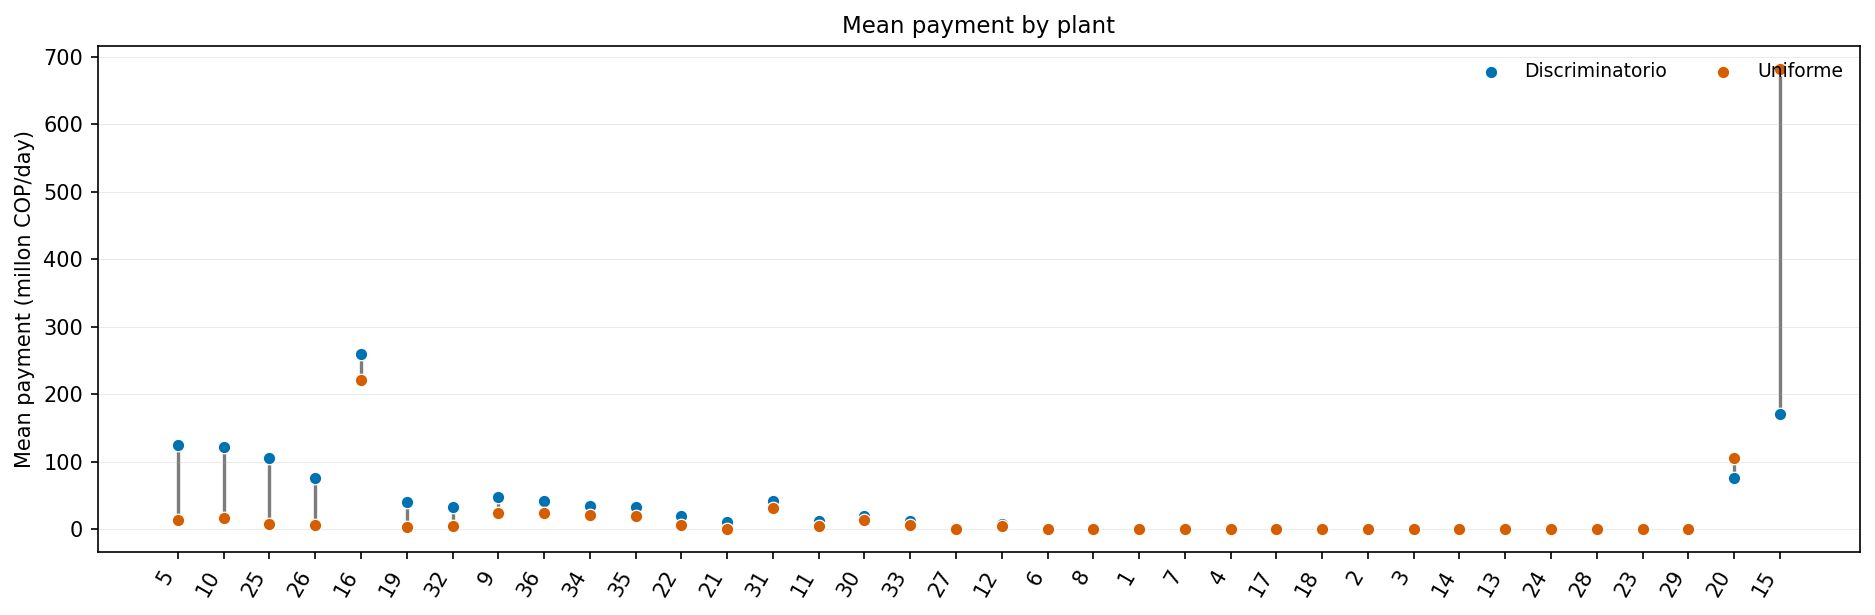

(    id_planta  mean_payment_uni  mean_markup_uni  n_boot_uni  \
 0           5         13.525426        12.435042         117   
 1          10         16.342106        15.262532         117   
 2          25          7.890075         7.419600         117   
 3          26          6.190905         6.016762         117   
 4          16        221.776001       119.522223         117   
 5          19          3.989058         3.773930         117   
 6          32          5.553389         5.224831         117   
 7           9         24.299444        20.485923         117   
 8          36         24.166712        18.878144         117   
 9          34         20.687007        16.977633         117   
 10         35         19.473285        14.924470         117   
 11         22          6.603699         4.904241         117   
 12         21          0.017821         0.013242         117   
 13         31         31.319433        30.215282         117   
 14         11          4

In [25]:
dumbbell_mean_metrics_by_planta(panel_uniforme5, panel_pay_as_bid5,plot_metric="mean_payment" )

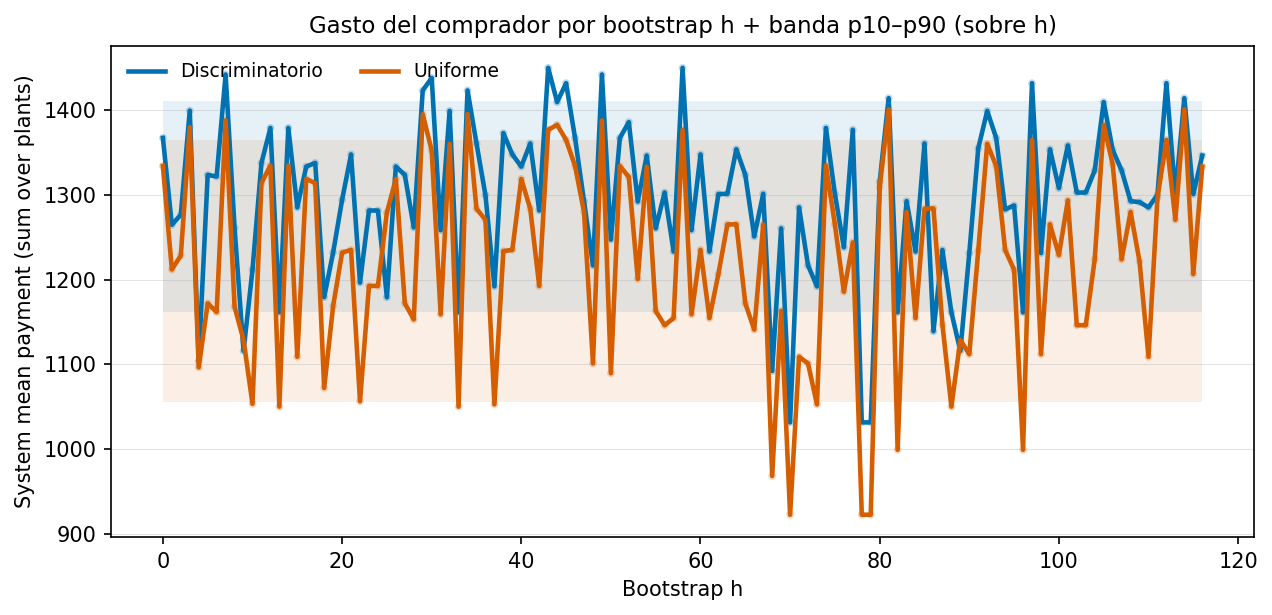

,h,uni,uni_smooth,disc,disc_smooth
0,0,1333.953898,1333.953898,1367.062103,1367.062103
1,1,1211.832807,1211.832807,1264.535454,1264.535454
2,2,1228.189532,1228.189532,1276.429725,1276.429725
3,3,1379.859979,1379.859979,1399.292218,1399.292218
4,4,1096.373075,1096.373075,1103.700721,1103.700721
...,...,...,...,...,...
112,112,1364.724086,1364.724086,1431.664670,1431.664670
113,113,1270.525022,1270.525022,1299.617007,1299.617007
114,114,1400.857310,1400.857310,1413.952101,1413.952101
115,115,1206.545435,1206.545435,1300.789050,1300.789050


In [26]:
plot_system_mean_payment_over_h_paper(
    panel_uniforme5,
    panel_pay_as_bid5,
    agg_across_plants="sum",   # gasto sistema
    smooth_window=0,           # o 5 para suavizar
    save_prefix="system_mean_payment_over_h"
)

## Asymetric

In [27]:
panel_uniforme36t100 = pd.read_csv('../asymetric/t100/panel_uniformAsymetric.csv')
panel_uniforme36t100.tail()

,t,h,id_planta,phi24,bid_scalar,q_dispatch24,price_paid24,payment24
421195,99,116,32,"[0.8675804521805, 0.8675804521805, 0.867580452...",2.077787,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5366075141279251, 0.300131158662796, 0.2729...",0.000000
421196,99,116,33,"[0.3650312218931, 0.3650312218931, 0.365031221...",1.148480,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5366075141279251, 0.300131158662796, 0.2729...",0.000000
421197,99,116,34,"[0.3158321485894, 0.3158321485894, 0.315832148...",0.625803,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5366075141279251, 0.300131158662796, 0.2729...",308.137080
421198,99,116,35,"[0.32106425803590005, 0.32106425803590005, 0.3...",0.740602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5366075141279251, 0.300131158662796, 0.2729...",52.316112
421199,99,116,36,"[0.29965534795040005, 0.29965534795040005, 0.2...",0.560108,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5366075141279251, 0.300131158662796, 0.2729...",337.811511


In [32]:
panel_uniforme36t100.rename(columns={"price_paid24":"precio24", "phi24":"phi", "q_dispatch24":"cantidades_despachadas"}, inplace=True)
# Calculamos el bid promedio por hora solo para id_planta 1
bid_promedio_horas = promedio_bid_por_hora(panel_uniforme36t100, id_planta_sel=1, col_precio24="precio24")

# Mostramos
print(bid_promedio_horas*1000)

0     488.422002
1     363.948808
2     274.316818
3     274.054187
4     297.873863
5     382.579279
6     437.837893
7     506.055722
8     514.008461
9     501.836380
10    534.426167
11    537.913454
12    522.981272
13    550.439800
14    587.489777
15    716.731068
16    692.578158
17    717.633530
18    807.863634
19    980.660976
20    887.286775
21    661.969612
22    540.140225
23    482.557012
Name: bid_promedio, dtype: float64


In [ ]:
panel_uniforme36 = pd.read_csv('../asymetric/t50/panel_uniform.csv')
panel_uniforme36.tail()

,t,h,id_planta,phi24,bid_scalar,q_dispatch24,price_paid24,payment24
89995,49,49,32,"[0.9298938564299, 0.9298938564299, 0.929893856...",1.489514,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.6072276101837158, 0.38279419554567334, 0.30...",0.000000
89996,49,49,33,"[0.37094405698399996, 0.37094405698399996, 0.3...",1.227553,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.6072276101837158, 0.38279419554567334, 0.30...",0.000000
89997,49,49,34,"[0.851733177763, 0.851733177763, 0.85173317776...",1.104336,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.6072276101837158, 0.38279419554567334, 0.30...",231.298626
89998,49,49,35,"[0.3498614797244, 0.3498614797244, 0.349861479...",0.440693,"[64.0, 0.0, 0.0, 0.0, 0.0, 0.0, 30.41808999999...","[0.6072276101837158, 0.38279419554567334, 0.30...",913.126445
89999,49,49,36,"[0.32947449471129997, 0.32947449471129997, 0.3...",0.728025,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.6072276101837158, 0.38279419554567334, 0.30...",447.352358


In [ ]:
panel_pay_as_bid36 = pd.read_csv('../asymetric/t50/panel_pay_as_bid.csv')
panel_pay_as_bid36.head()

,t,h,id_planta,phi24,bid_scalar,q_dispatch24,price_paid24,payment24
0,0,0,1,"[0.8268800727022, 0.8268800727022, 0.826880072...",1.925478,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000
1,0,0,2,"[1.7148847113195, 1.7148847113195, 1.714884711...",3.583072,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000
2,0,0,3,"[1.6176457155191, 1.6176457155191, 1.617645715...",3.484885,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000
3,0,0,4,"[0.1917712637032, 0.1917712637032, 0.191771263...",1.073002,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.050635
4,0,0,5,"[0.18770034673480002, 0.18770034673480002, 0.1...",0.950261,"[164.0, 164.0, 44.05107000000032, 0.0, 164.0, ...","[0.9502607600221634, 0.9502607600221634, 0.950...",3470.400825


In [ ]:
panel_uniforme36.rename(columns={"price_paid24":"precio24", "phi24":"phi", "q_dispatch24":"cantidades_despachadas"}, inplace=True)
panel_pay_as_bid36.rename(columns={"price_paid24":"precio24", "phi24":"phi", "q_dispatch24":"cantidades_despachadas"}, inplace=True)

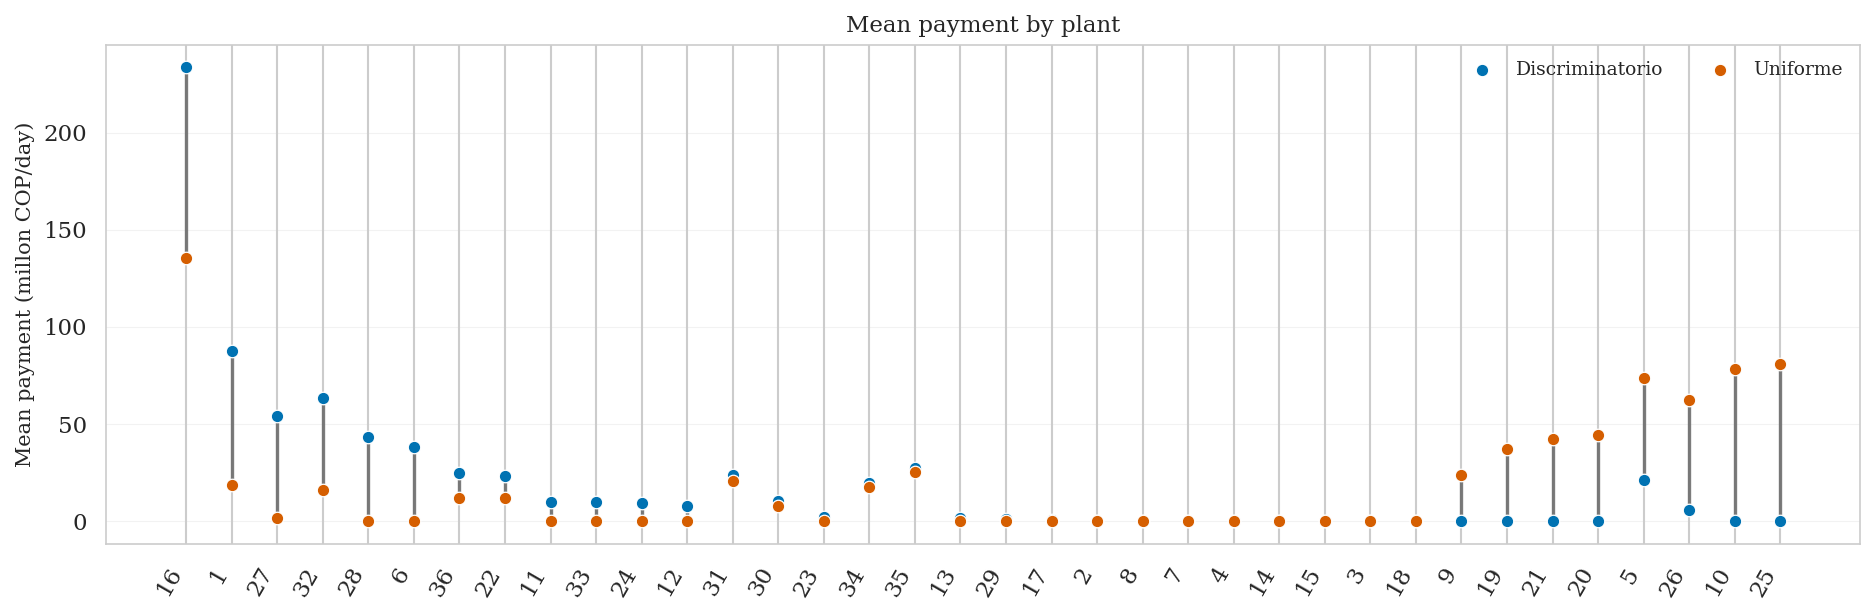

(    id_planta  mean_payment_uni  mean_markup_uni  n_boot_uni  \
 0          16        135.668765        36.528526          50   
 1           1         18.461072         5.303575          50   
 2          27          1.720277         1.454338          50   
 3          32         15.917266        14.437991          50   
 4          28          0.000000         0.000000          50   
 5           6          0.000000         0.000000          50   
 6          36         11.937717         8.243455          50   
 7          22         11.753838         5.895816          50   
 8          11          0.117643         0.113853          50   
 9          33          0.213541         0.160091          50   
 10         24          0.000000         0.000000          50   
 11         12          0.319202         0.282794          50   
 12         31         20.859528        19.643104          50   
 13         30          7.689727         6.893398          50   
 14         23          0

In [ ]:
dumbbell_mean_metrics_by_planta(panel_uniforme36, panel_pay_as_bid36,plot_metric="mean_payment" )

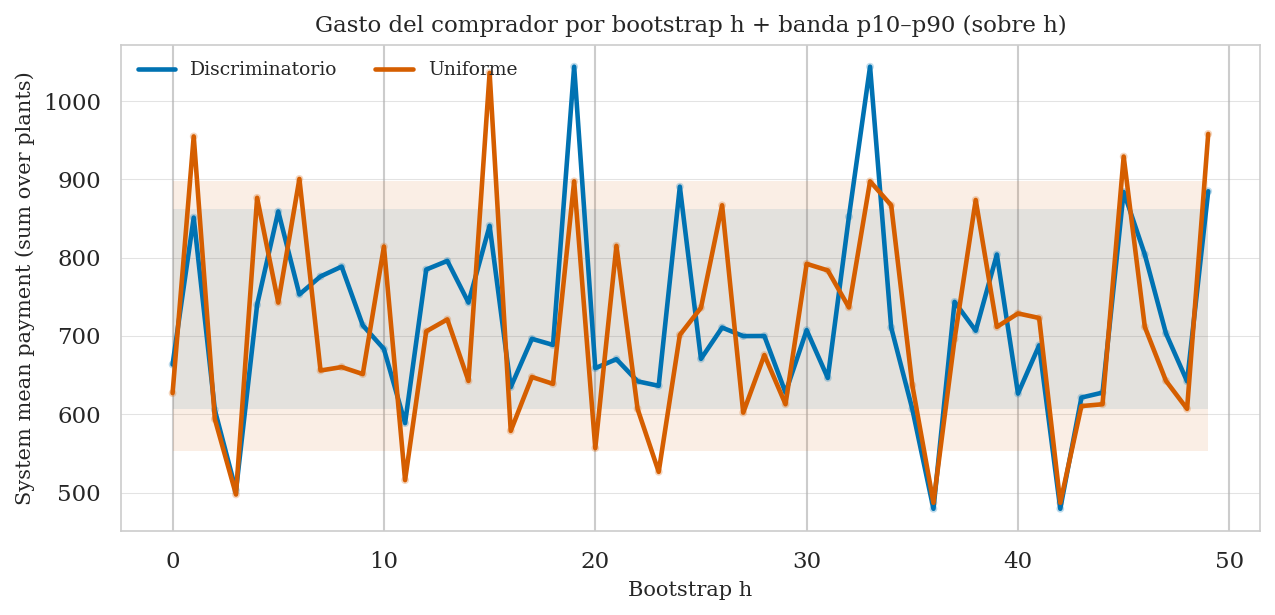

,h,uni,uni_smooth,disc,disc_smooth
0,0,626.978212,626.978212,663.538127,663.538127
1,1,954.939722,954.939722,851.272698,851.272698
2,2,593.783870,593.783870,605.349636,605.349636
3,3,497.460682,497.460682,502.568549,502.568549
4,4,876.480188,876.480188,739.857946,739.857946
5,5,742.631562,742.631562,859.077959,859.077959
6,6,900.616803,900.616803,753.040572,753.040572
7,7,655.865171,655.865171,776.086462,776.086462
8,8,660.252475,660.252475,788.640934,788.640934
9,9,651.304276,651.304276,713.539392,713.539392


In [ ]:
plot_system_mean_payment_over_h_paper(
    panel_uniforme36,
    panel_pay_as_bid36,
    agg_across_plants="sum",   # gasto sistema
    smooth_window=0,           # o 5 para suavizar
    save_prefix="system_mean_payment_over_h"
)

## Cotejo datos reales

In [30]:
import ast

def promedio_bid_por_hora(df_sim, id_planta_sel=1, col_precio24="precio24"):
    """
    Calcula el promedio por hora de la simulación para un id_planta específico.
    
    Convierte strings que parecen listas en listas reales.
    """
    # Filtrar solo la planta deseada
    df_filtrado = df_sim[df_sim["id_planta"] == id_planta_sel].copy()
    
    # Asegurarse de que la columna precio24 sea lista real
    def asegurar_lista(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)  # convierte string '[1,2,3]' en lista [1,2,3]
            except:
                return []
        elif isinstance(x, (list, np.ndarray)):
            return x
        else:
            return []
    
    df_filtrado[col_precio24] = df_filtrado[col_precio24].apply(asegurar_lista)
    
    # Calcular promedio por hora
    promedio_horas = []
    for h in range(24):
        valores_h = [row[h] for row in df_filtrado[col_precio24] if len(row) > h]
        # Ignorar ceros
        valores_h = [v for v in valores_h if v != 0]
        promedio = np.mean(valores_h) if len(valores_h) > 0 else np.nan
        promedio_horas.append(promedio)
    
    return pd.Series(promedio_horas, index=range(24), name="bid_promedio")


In [ ]:
# Calculamos el bid promedio por hora solo para id_planta 1
bid_promedio_horas = promedio_bid_por_hora(panel_uniforme36, id_planta_sel=1, col_precio24="precio24")

# Mostramos
print(bid_promedio_horas*1000)


0      552.615924
1      412.539849
2      316.321888
3      315.063250
4      356.733459
5      457.426373
6      489.943835
7      593.417043
8      608.698466
9      581.547843
10     685.850103
11     703.568572
12     657.702552
13     743.188188
14     801.511183
15     975.723848
16     923.802124
17     982.533736
18    1150.961764
19    1270.604237
20    1194.065640
21     885.284652
22     719.547647
23     527.208303
Name: bid_promedio, dtype: float64


In [ ]:
import pandas as pd

precio_horario = pd.read_csv('../../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]
precio_horario.head()



,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
288,PB_Int,2025-06-01 00:00:00,PT1H,COP/kWh,TXF,101.2
289,PB_Int,2025-06-01 01:00:00,PT1H,COP/kWh,TXF,101.2
290,PB_Int,2025-06-01 02:00:00,PT1H,COP/kWh,TXF,101.2
291,PB_Int,2025-06-01 03:00:00,PT1H,COP/kWh,TXF,101.2
292,PB_Int,2025-06-01 04:00:00,PT1H,COP/kWh,TXF,101.2


In [ ]:
def promedio_precio_horario(df_real, col_fecha="FechaHora", col_valor="Valor"):
    """
    Calcula el promedio por hora del precio real.
    """
    df = df_real.copy()
    
    # Asegurarse de que la columna de fecha sea datetime
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    
    # Crear columna de hora
    df["hora"] = df[col_fecha].dt.hour
    
    # Agrupar por hora y sacar la media
    promedio_horas = df.groupby("hora")[col_valor].mean()
    
    # Reindexar para asegurar 0-23 horas
    promedio_horas = promedio_horas.reindex(range(24))
    
    return promedio_horas.rename("precio_promedio")
precio_promedio_horas = promedio_precio_horario(precio_horario, col_fecha="FechaHora", col_valor="Valor")
print(precio_promedio_horas)


hora
0     119.764321
1     120.836605
2     120.181173
3     119.892222
4     121.671420
5     123.630617
6     124.844012
7     124.077901
8     124.283765
9     123.359198
10    126.744877
11    131.328395
12    128.940123
13    136.973580
14    144.289815
15    161.316358
16    166.662099
17    159.324691
18    227.793765
19    421.606173
20    249.581914
21    166.762716
22    144.334383
23    131.005247
Name: precio_promedio, dtype: float64


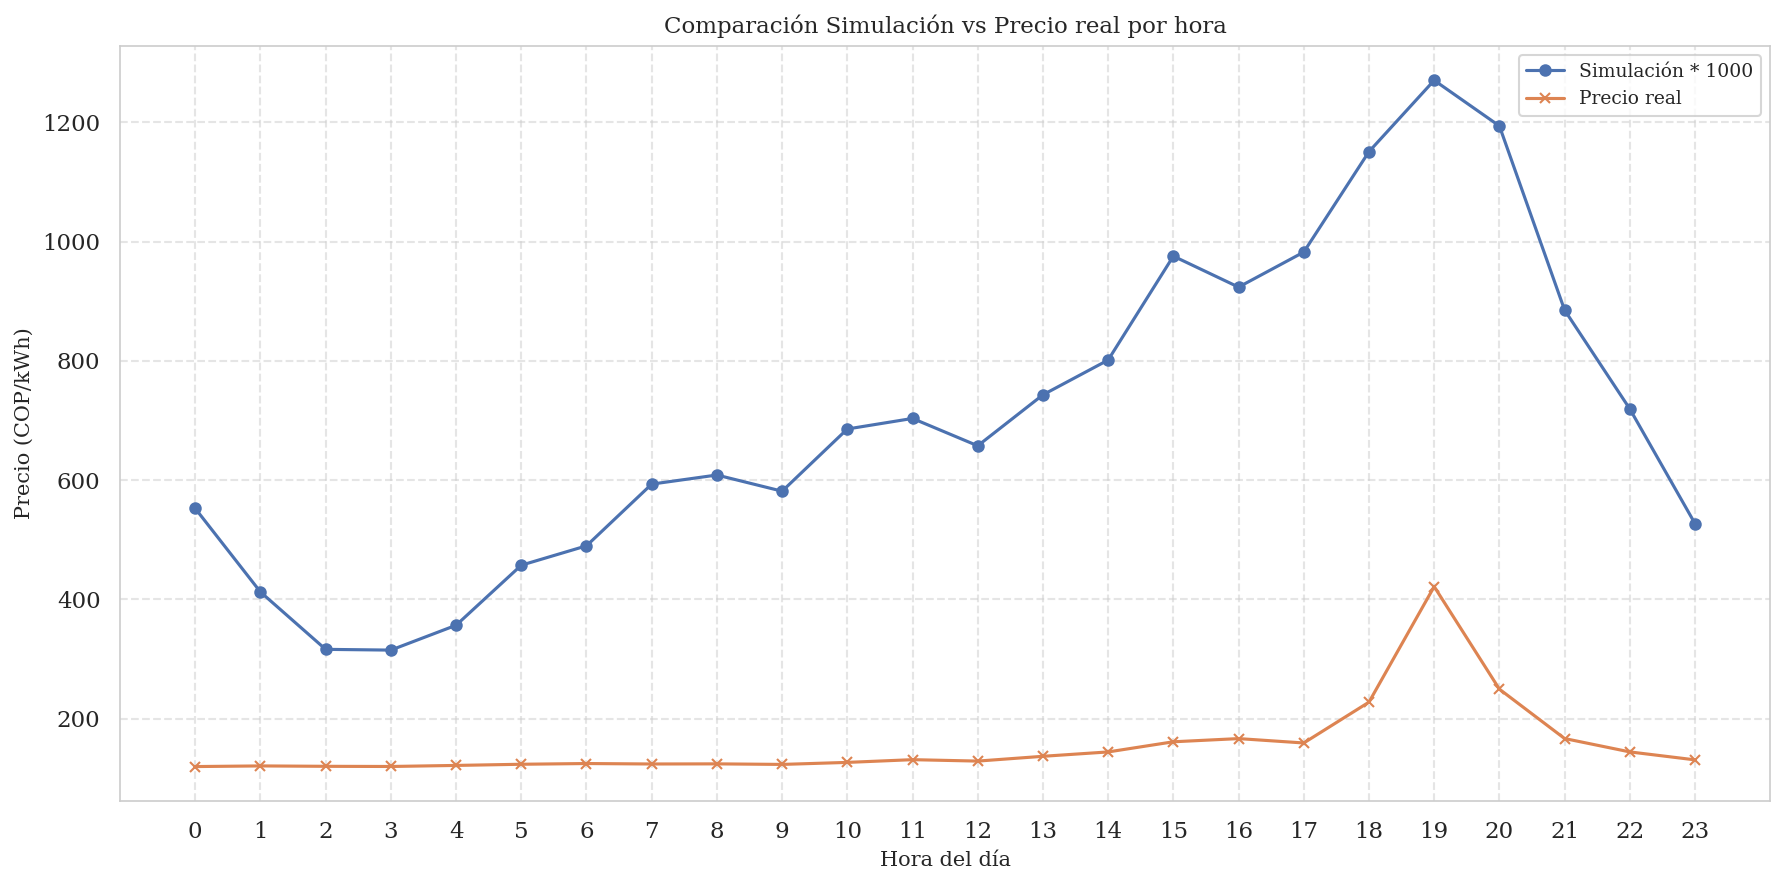

In [ ]:
import matplotlib.pyplot as plt

# bid_promedio_horas: array de 24 valores de tu simulación
# precio_promedio_horas: array de 24 valores del precio real

hora = range(24)  # eje x: horas del día 0-23

plt.figure(figsize=(12,6))
plt.plot(hora, bid_promedio_horas * 1000, label="Simulación * 1000", marker='o', markersize=5, linestyle='-')
plt.plot(hora, precio_promedio_horas, label="Precio real", marker='x', markersize=5, linestyle='-')

plt.xlabel("Hora del día")
plt.ylabel("Precio (COP/kWh)")
plt.title("Comparación Simulación vs Precio real por hora")
plt.xticks(hora)  # mostrar todas las horas
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
## desde las 4 hasta las 9pm se empieza a usar mucha energia termica y el precio de bolsa que registarn se parece mucho al precio de bolsa que yo calculo

In [ ]:
import pandas as pd
import numpy as np
import ast

def max_bid_por_hora(df_sim, id_planta_sel=1, col_precio24="precio24"):
    """
    Calcula el valor máximo por hora de la simulación para un id_planta específico,
    ignorando ceros. Convierte strings que parecen listas en listas reales.
    """
    # Filtrar planta deseada
    df_filtrado = df_sim[df_sim["id_planta"] == id_planta_sel].copy()
    
    # Convertir strings a listas
    def asegurar_lista(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return []
        elif isinstance(x, (list, np.ndarray)):
            return list(x)
        else:
            return []
    
    df_filtrado[col_precio24] = df_filtrado[col_precio24].apply(asegurar_lista)
    
    # Calcular máximo por hora
    max_horas = []
    for h in range(24):
        valores_h = [row[h] for row in df_filtrado[col_precio24] if len(row) > h and row[h] != 0]
        max_val = np.max(valores_h) if valores_h else np.nan
        max_horas.append(max_val)
    
    return pd.Series(max_horas, index=range(24), name="bid_max")

# --- Uso ---
bid_max_horas = max_bid_por_hora(panel_uniforme36, id_planta_sel=1)
print(bid_max_horas)


0     1.356474
1     1.174656
2     0.989712
3     0.985741
4     1.165454
5     1.247317
6     1.287166
7     1.441434
8     1.441434
9     1.441434
10    1.813596
11    1.813596
12    1.650648
13    1.880720
14    1.880720
15    2.014263
16    2.014263
17    2.014263
18    2.145311
19    2.396284
20    2.396284
21    1.917000
22    1.813596
23    1.356474
Name: bid_max, dtype: float64


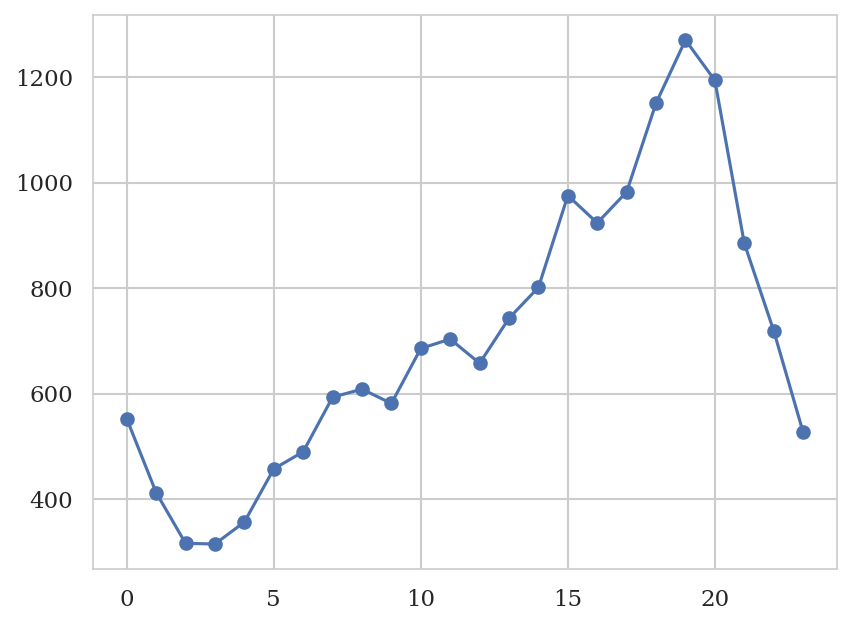

In [ ]:
hora = range(24)
plt.plot(hora, bid_promedio_horas*1000, label="Simulación * 1000", marker='o')


In [ ]:
panel_uniforme3

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,1.912630,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,2.608649,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,2.511410,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,1.085535,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,1.273450,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.18770034673480002, 0.18770034673480002, 0.1..."
...,...,...,...,...,...,...,...
4207,32,0,116,1.143899,"[255.0, 255.0, 130.05107000000032, 64.31019999...","[1.2237739728221892, 1.200067901743412, 1.1438...","[0.058149440727, 0.058149440727, 0.05814944072..."
4208,33,0,116,1.226741,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 36.0, 36.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.22937391...","[0.3329769608998, 0.3329769608998, 0.332976960..."
4209,34,0,116,1.349824,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.4560598724902, 0.4560598724902, 0.456059872..."
4210,35,0,116,1.201794,"[64.0, 0.0, 0.0, 0.0, 0.0, 0.0, 64.0, 64.0, 64...","[1.2237739728221892, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3080295103705, 0.3080295103705, 0.308029510..."


In [ ]:
import pandas as pd
import numpy as np

def promedio_bid_por_hora(df_sim, id_planta_sel=1, col_precio24="precio24"):
    """
    Calcula el promedio por hora de un id_planta específico,
    usando los valores >0 si existen, sino toma 0.
    """
    # Filtrar planta
    df_filtrado = df_sim
    # Promedio por componente (hora)
    promedio_horas = []
    for h in range(24):
        valores_h = []
        for row in df_filtrado[col_precio24]:
            if len(row) > h:
                v = row[h]
                if v > 0:
                    valores_h.append(v)
        # Si no hay valores >0, poner 0
        promedio = np.mean(valores_h) if valores_h else 0
        promedio_horas.append(promedio)
    
    return pd.Series(promedio_horas, index=range(24), name="bid_promedio")

bid_promedio_horas = promedio_bid_por_hora(panel_uniforme3, id_planta_sel=1)
print(bid_promedio_horas)


TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
bid_promedio_horas_uniforme5 = promedio_bid_por_hora(panel_uniforme5, id_planta_sel=1)
print(bid_promedio_horas_uniforme5)


TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
data_base = pd.read_csv('../../results/fechas_117/TERMICA/inputRed.csv', sep=';')
data_base.head()

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...","830,9443583100","889,2800000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",1
1,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...","826,8800727022","889,2800000000","[233350.0, 205300.0, 951070.0, 872530.0, 10147...",2025-04-02,"13,0000000000",1
2,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...","828,0012488115","889,2800000000","[895720.0, 609450.0, 422830.0, 348240.0, 55249...",2025-04-03,"7,0000000000",1
3,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...","695,9863476767","889,2800000000","[270253.61000000034, 466977.03000000026, 23921...",2025-04-04,"2,0000000000",1
4,3ENA,"[200000.0, 200000.0, 200000.0, 200000.0, 20000...","767,6943114687","889,2800000000","[530630.0, 268940.0, 104170.0, 406420.0, 39726...",2025-04-07,"5,0000000000",1


In [ ]:
# Reemplazar coma por punto y convertir a float
data_base['phi_num'] = data_base['phi'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Ahora puedes usar describe()
print(data_base['phi_num'].describe())


count    4212.000000
mean      681.396597
std       555.220179
min         0.000000
25%       226.570839
50%       604.294567
75%       946.633404
max      2308.658787
Name: phi_num, dtype: float64


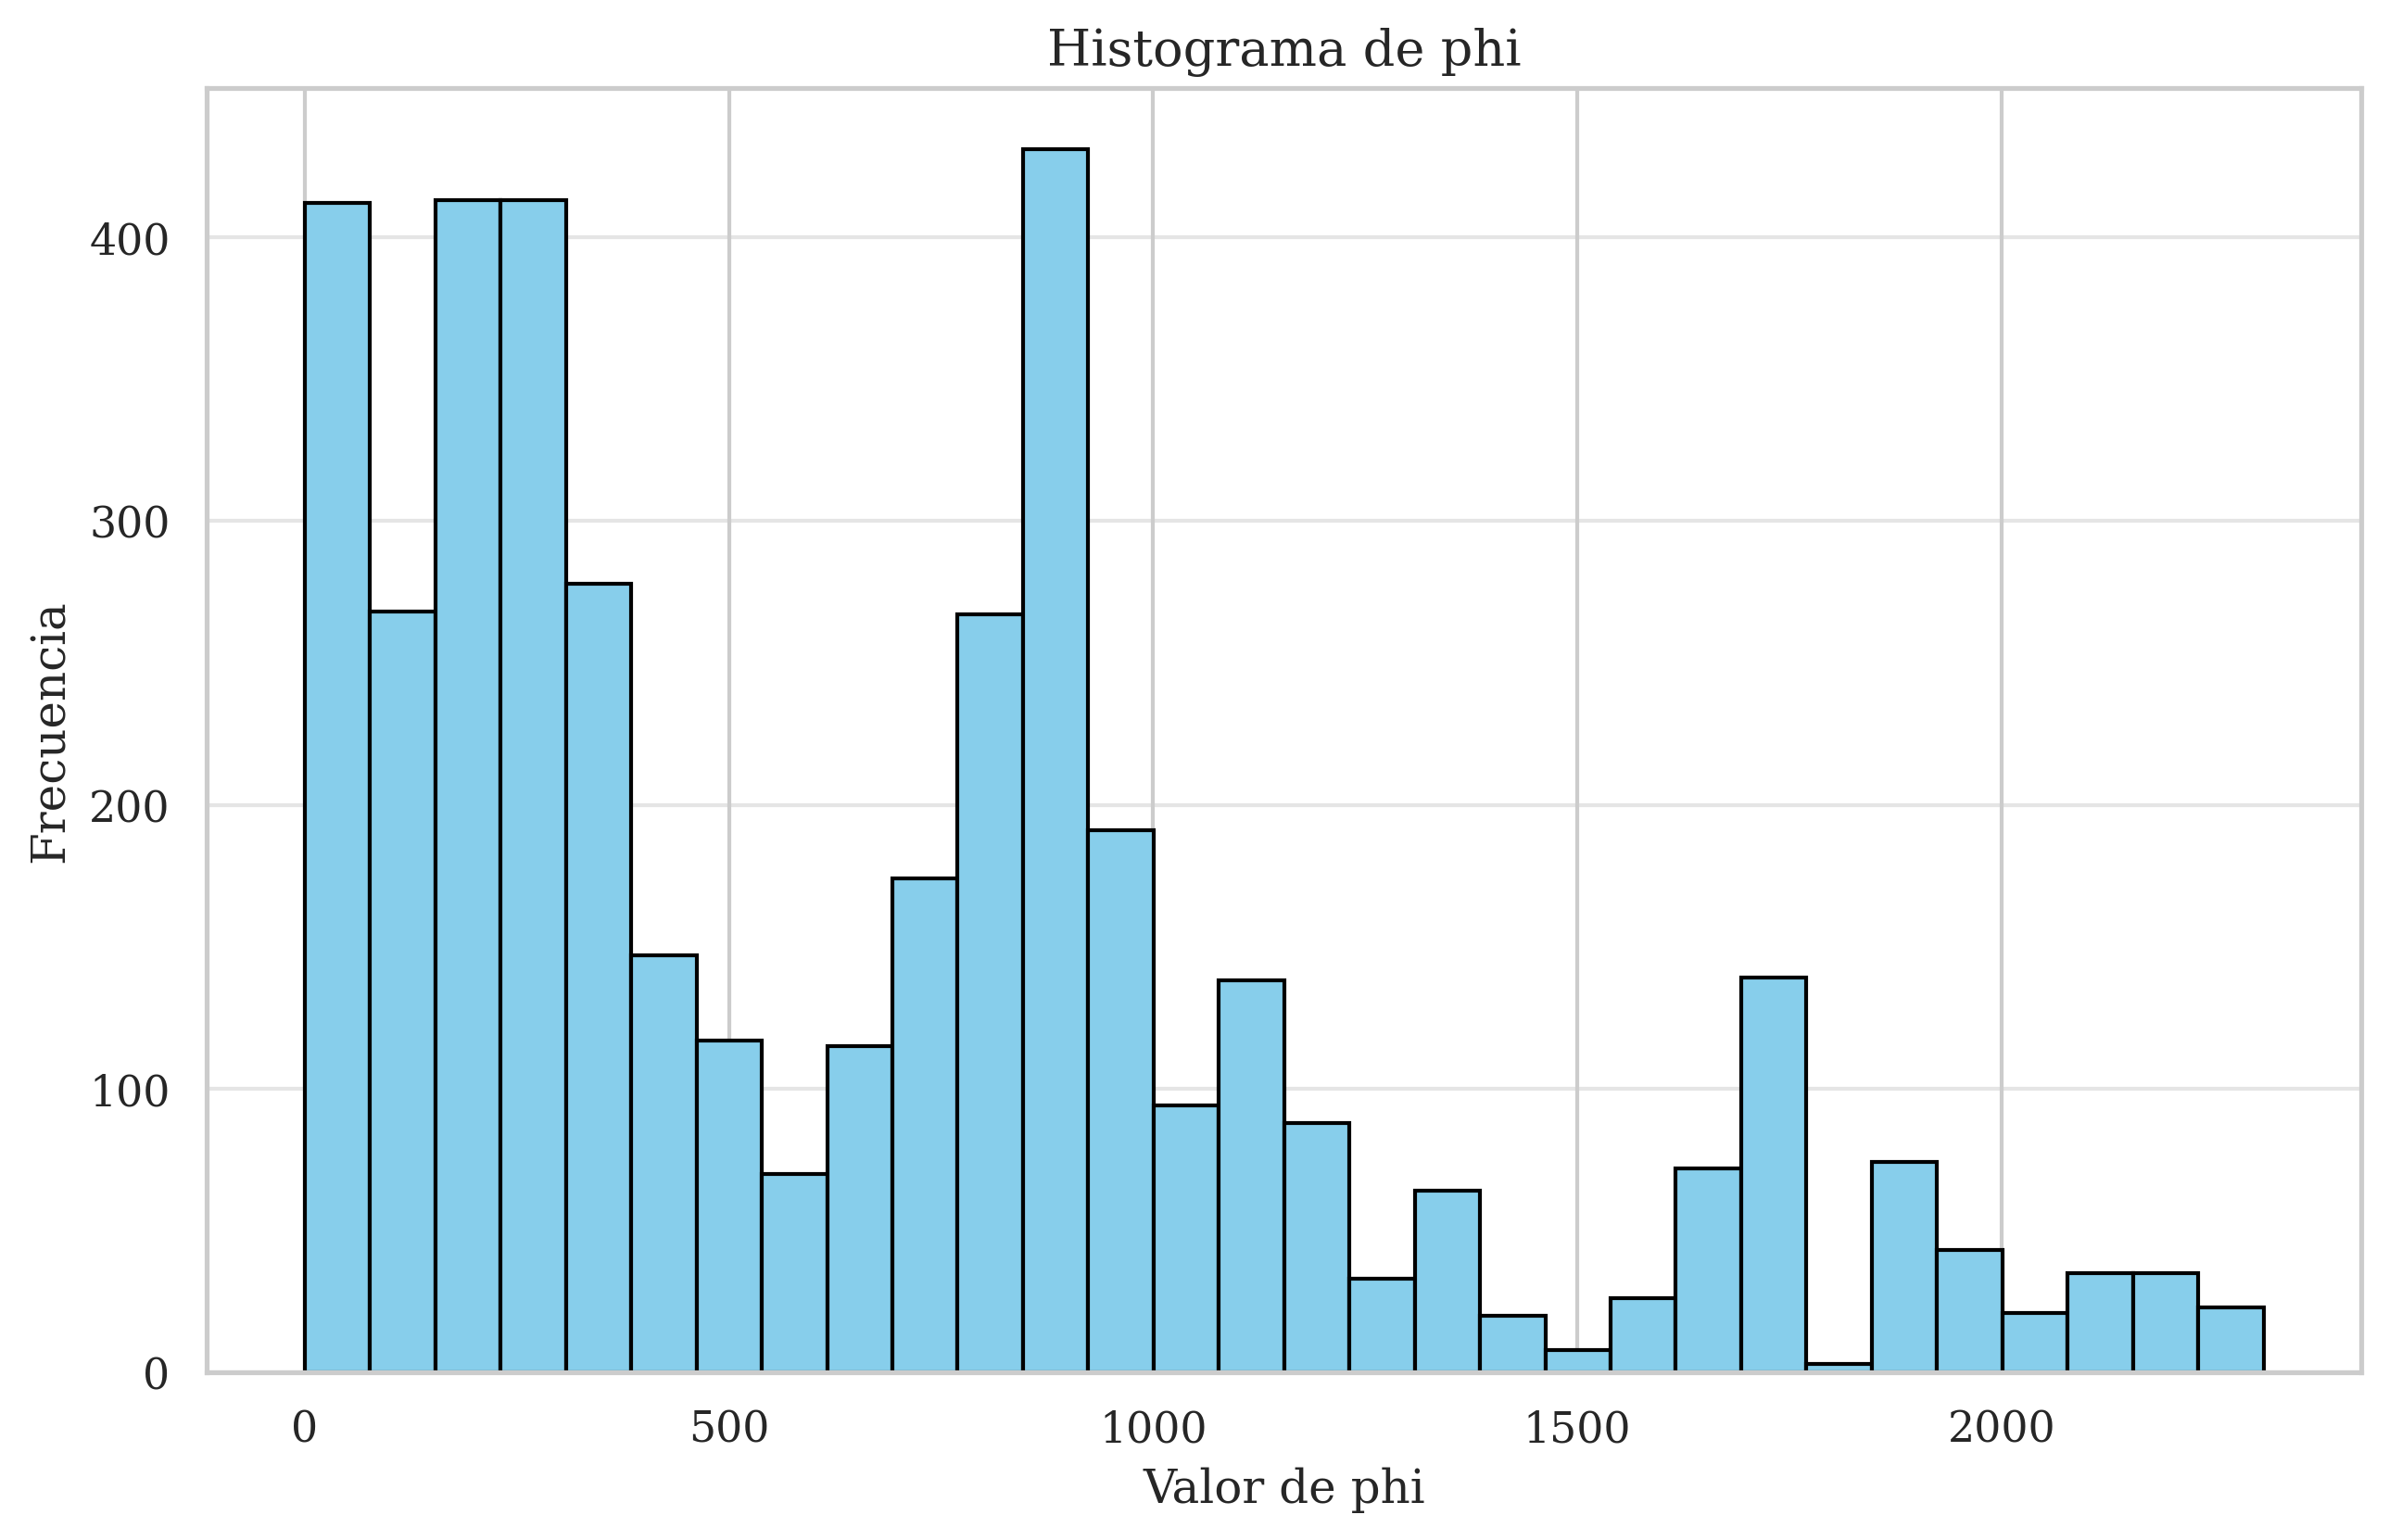

In [ ]:
import matplotlib.pyplot as plt

# Asegurarse de que 'phi_num' sea float
phi = data_base['phi_num']

# Histograma
plt.figure(figsize=(10,6))
plt.hist(phi, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Valor de phi')
plt.ylabel('Frecuencia')
plt.title('Histograma de phi')
plt.grid(axis='y', alpha=0.5)
plt.show()
